In [461]:
import torchvision
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [462]:


train_data = datasets.FashionMNIST(
    root='data2',
    train= True,
    transform=ToTensor(),
    download=True
)
test_data = datasets.FashionMNIST(
    root='data2',
    train= False,
    transform=ToTensor(),
    download=True
)

In [463]:
class_names= train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [464]:
train_data_loader= DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)
test_data_loader= DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

In [465]:
train_features_batch, train_labels_batch= next(iter(train_data_loader))

train_features_batch.size() ,train_labels_batch.size()

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [466]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [467]:

class CnnModel(nn.Module):

    def __init__(self, in_features, out_features, hidden_units=10):
        super().__init__()

        self.block1= nn.Sequential(
            nn.Conv2d(in_channels=in_features,  # conv2d Står för 2d data HEIGHT, WIDTH
                                      out_channels=hidden_units, 
                                      kernel_size=3, 
                                      stride=1, 
                                      padding= 1), #Paramettrar vi kan vi kan justera kallas hyperparametrar
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,  
                out_channels=hidden_units, 
                kernel_size=3, 
                stride=1, 
                padding= 1),
        
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.block2= nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,  
                out_channels=hidden_units, 
                kernel_size=3, 
                stride=1, 
                padding= 1),

            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,  
                out_channels=hidden_units, 
                kernel_size=3, 
                stride=1, 
                padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,  # trick to calculate whats needed
                      out_features=out_features)
        )


    def forward(self, x):
        x= self.block1(x)
        #print(x.shape)
        x= self.block2(x)
        #print(x.shape)
        
        x= self.classifier(x)
        #print(x.shape)
        return x

In [468]:
torch.manual_seed(42)

model= CnnModel(in_features=1,
                hidden_units=10,
                out_features=len(class_names))

model.state_dict()

OrderedDict([('block1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
            

### Dummy data

In [469]:

#DEMMY DATA

torch.manual_seed(42)

image= torch.randn(size=(32, 3, 64, 64))
test_image= image[0]

print(image.shape)
test_image

torch.Size([32, 3, 64, 64])


tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.0780],
         [-1.4647, -1.9571,  0.1017,  ..., -1

### kolla shape efter lager med dummy data

In [470]:
conv_layer= nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0)

conv_output= conv_layer(test_image)

conv_output.shape

torch.Size([10, 62, 62])

In [471]:
dummy= torch.randn(size=(32,1,28,28))



dummy_test= model(dummy)

dummy_test.shape

torch.Size([32, 10])

### Loss fn och optimizer

In [472]:
loss_fn= nn.CrossEntropyLoss()
optim= torch.optim.SGD(params=model.parameters(), lr= 0.1)

### TRAIN + function

In [473]:
def train_one_epoch(model: nn.Module, optimizer:torch.optim.SGD, loss_fn: nn.CrossEntropyLoss, dataloader, device):
    model= model.to(device)
    model.train()
    running_loss=0.0
    total_samples=0
    correct_pred=0


    for images, labels in dataloader:
        images= images.to(device)
        labels= labels.to(device)
        
        #1. forward pass
        y_logits= model(images)

        #2. loss ?

        loss = loss_fn(y_logits, labels)
        running_loss += loss.item() * images.size(0)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_preds= y_logits.argmax(dim=1)
        correct_pred += torch.eq(y_preds, labels).sum().item()
        total_samples += labels.size(0)

    loss= running_loss / total_samples
    acc= correct_pred / total_samples

    return loss, acc

In [474]:
def eval_model(model, device, dataloader, loss_fn):
    model= model.to(device)
    model.eval()

    running_loss=0.0
    correct_preds= 0
    total_samples= 0


    with torch.inference_mode():
        for images, labels in dataloader:
            images= images.to(device)
            labels= labels.to(device)
            

            y_preds= model(images)
            loss= loss_fn(y_preds, labels)
            running_loss += loss.item() * images.size(0)
        
            preds= y_preds.argmax(dim=1)
            correct_preds += torch.eq(preds, labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss= running_loss / total_samples
    epoch_acc= correct_preds/ total_samples

    return epoch_loss, epoch_acc



In [475]:

EPOCHS=3

history= {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'model_name': []
}

for epoch in range(EPOCHS):
    loss, acc= train_one_epoch(model, optim, loss_fn, train_data_loader, device)
    test_loss, test_acc= eval_model(model, device, test_data_loader, loss_fn)

    history['train_loss'].append(loss)
    history['train_acc'].append(acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['model_name'].append(model._get_name()) # eller __class__.__name__


    print(f'epoch: {epoch} / {EPOCHS}')
    print(f'train loss: {loss:.5f} ')
    print(f'train acc: {acc:.5f} \n')
    
    print(f'test loss: {test_loss:.5f} ')
    print(f'test acc: {test_acc:.5f} \n')

epoch: 0 / 3
train loss: 0.58545 
train acc: 0.78750 

test loss: 0.40746 
test acc: 0.85650 

epoch: 1 / 3
train loss: 0.35991 
train acc: 0.86985 

test loss: 0.34731 
test acc: 0.87170 

epoch: 2 / 3
train loss: 0.32186 
train acc: 0.88298 

test loss: 0.34375 
test acc: 0.87110 



In [476]:
import pandas as pd


history= pd.DataFrame(history)
history

,train_loss,train_acc,test_loss,test_acc,model_name
0,0.585453,0.787500,0.407462,0.8565,CnnModel
1,0.359906,0.869850,0.347314,0.8717,CnnModel
2,0.321864,0.882983,0.343749,0.8711,CnnModel


### skapa och evaluera random predictions med bästa modellen?
gjort innan med eval funktionen?

In [477]:
import matplotlib.pyplot as plt
import random

test_samples= []
test_labels= []

for img, label in random.sample(list(test_data), k=9):
    test_samples.append(img)
    test_labels.append(label)

test_samples[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Dress')

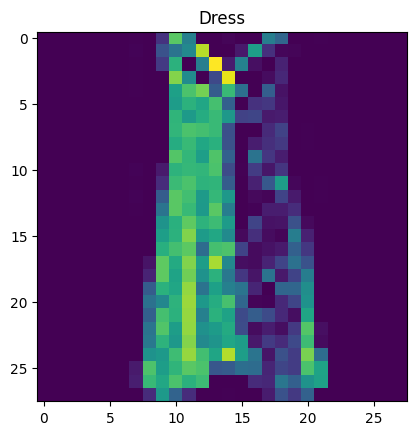

In [478]:
plt.imshow(test_samples[1].squeeze())
plt.title(class_names[test_labels[1]])

In [479]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


with torch.inference_mode():
    all_labels= []
    all_preds= []

    for img, labels in test_data_loader:
        logits= model(img)

        preds= logits.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

 T-shirt/top       0.85      0.76      0.80      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.84      0.79      0.81      1000
       Dress       0.89      0.87      0.88      1000
        Coat       0.81      0.74      0.77      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.60      0.74      0.66      1000
     Sneaker       0.97      0.90      0.93      1000
         Bag       0.95      0.98      0.97      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



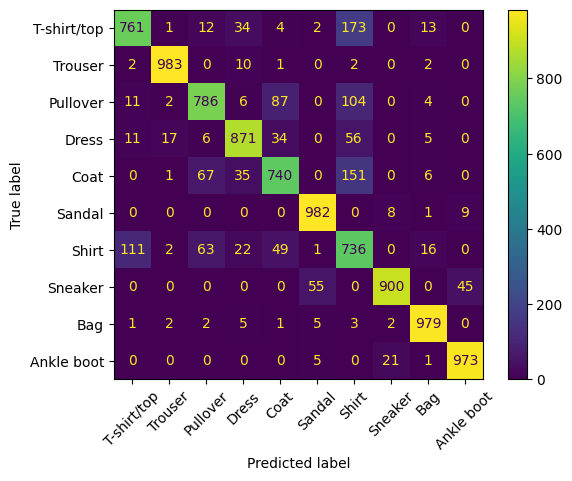

In [480]:
cm= confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=class_names)
disp.plot()
plt.xticks(rotation= 45)
plt.show()

# SPARA och ladda MODELLEN

In [481]:
from pathlib import Path

dir= Path('models')
dir.mkdir(parents=True, exist_ok=True)

MODEL_NAME= 'CNNMODEL.pth'
MODEL_SAVE_PATH= dir/ MODEL_NAME

torch.save(obj= model.state_dict(), f=MODEL_SAVE_PATH)
print(f'saved model to: {MODEL_SAVE_PATH}')

saved model to: models\CNNMODEL.pth


In [482]:
loadel_model= CnnModel(in_features=1, out_features=len(class_names), hidden_units=10)

loadel_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loadel_model= loadel_model.to(device)

In [483]:
history

,train_loss,train_acc,test_loss,test_acc,model_name
0,0.585453,0.787500,0.407462,0.8565,CnnModel
1,0.359906,0.869850,0.347314,0.8717,CnnModel
2,0.321864,0.882983,0.343749,0.8711,CnnModel


In [484]:
EPOCHS=3

history2= {

    'test_loss': [],
    'test_acc': [],
    'model_name': []
}

for epoch in range(EPOCHS):
    test_loss, test_acc= eval_model(loadel_model, device, test_data_loader, loss_fn)

    history2['test_loss'].append(test_loss)
    history2['test_acc'].append(test_acc)
    history2['model_name'].append(loadel_model._get_name()) # eller __class__.__name__


    print(f'epoch: {epoch} / {EPOCHS}')

    
    print(f'test loss: {test_loss:.5f} ')
    print(f'test acc: {test_acc:.5f} \n')

epoch: 0 / 3
test loss: 0.34375 
test acc: 0.87110 

epoch: 1 / 3
test loss: 0.34375 
test acc: 0.87110 

epoch: 2 / 3
test loss: 0.34375 
test acc: 0.87110 



In [485]:
history2= pd.DataFrame(history2)
history2

,test_loss,test_acc,model_name
0,0.343749,0.8711,CnnModel
1,0.343749,0.8711,CnnModel
2,0.343749,0.8711,CnnModel
